In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install geopandas fiona shapely pyproj matplotlib --quiet

Mounted at /content/drive


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

file_path = '/content/drive/MyDrive/Journey_Links.geojson'

gdf = gpd.read_file(file_path)

print(gdf.shape)
print(gdf.crs)
gdf.head()

(240, 14)
EPSG:4326


,OBJECTID,JOURNEY_LINK_ID,JOURNEY_LINK_DESCRIPTION,JOURNEY_START,JOURNEY_START_DIRECTION_TYPE,JOURNEY_END,JOURNEY_END_DIRECTION_TYPE,MINIMUM_PLATE_MATCHES,CANDIDATE_COUNT,KPI_PRIORITY_LINK,JOURNEY_START_DIRECTION_DESC,JOURNEY_END_DIRECTION_DESC,SHAPESTLength,geometry
0,1,8,Bedminster Parade IB > 3 Lamps OB,Bedminster Parade IB,IB,3 Lamps OB,OB,1,9,Yes,Inbound,Outbound,1433.987888,"LINESTRING (-2.59338 51.44421, -2.59269 51.444..."
1,2,9,Bedminster Parade OB > Parson St Gyratory,Bedminster Parade OB,OB,Parson St Gyratory,NA,1,9,No,Outbound,None,2344.374168,"LINESTRING (-2.59342 51.4442, -2.59383 51.4438..."
2,3,21,M32 OB > Fishponds Rd/Straits Pde EB,M32 OB,OB,Fishponds Rd/Straits Pde EB,EB,1,9,Yes,Outbound,East bound,5094.227267,"LINESTRING (-2.58273 51.46044, -2.58234 51.460..."
3,4,29,3 Lamps IB > M32 OB,3 Lamps IB,IB,M32 OB,OB,1,9,Yes,Inbound,Outbound,2035.817823,"LINESTRING (-2.57872 51.44463, -2.57871 51.444..."
4,5,31,3 Lamps IB > Victoria St NB,3 Lamps IB,IB,Victoria St NB,NB,1,9,Yes,Inbound,North bound,1237.394135,"LINESTRING (-2.57854 51.44477, -2.57871 51.444..."


In [ ]:


# Load your CSV
df = pd.read_csv('/content/drive/MyDrive/continuous_air_quality_2324.csv')

# Extract relevant columns and drop duplicate rows
df_unique = df[['SITE_ID', 'LOCATION', 'EASTING', 'NORTHING']].drop_duplicates()

# Reset index
df_unique = df_unique.reset_index(drop=True)

# Preview
print(f"Total unique rows: {len(df_unique)}")
df_unique.head()

Total unique rows: 8


/tmp/ipykernel_4500/1456504104.py:4: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/continuous_air_quality_2324.csv')


,SITE_ID,LOCATION,EASTING,NORTHING
0,203,Brislington Depot,361178,171566
1,215,Parson Street School,358042,170582
2,270,Wells Road,360903,170024
3,452,AURN St Pauls,359488,173924
4,463,Fishponds Road,362926,175590


In [ ]:
# Convert the coordiante system to match the GeoJson
from shapely.geometry import Point


gdf_sensor = gpd.GeoDataFrame(
    df_unique,
    geometry=gpd.points_from_xy(df_unique['EASTING'], df_unique['NORTHING']),
    crs='EPSG:27700'  # British National Grid
)
gdf_sensor = gdf_sensor.to_crs(epsg=4326)


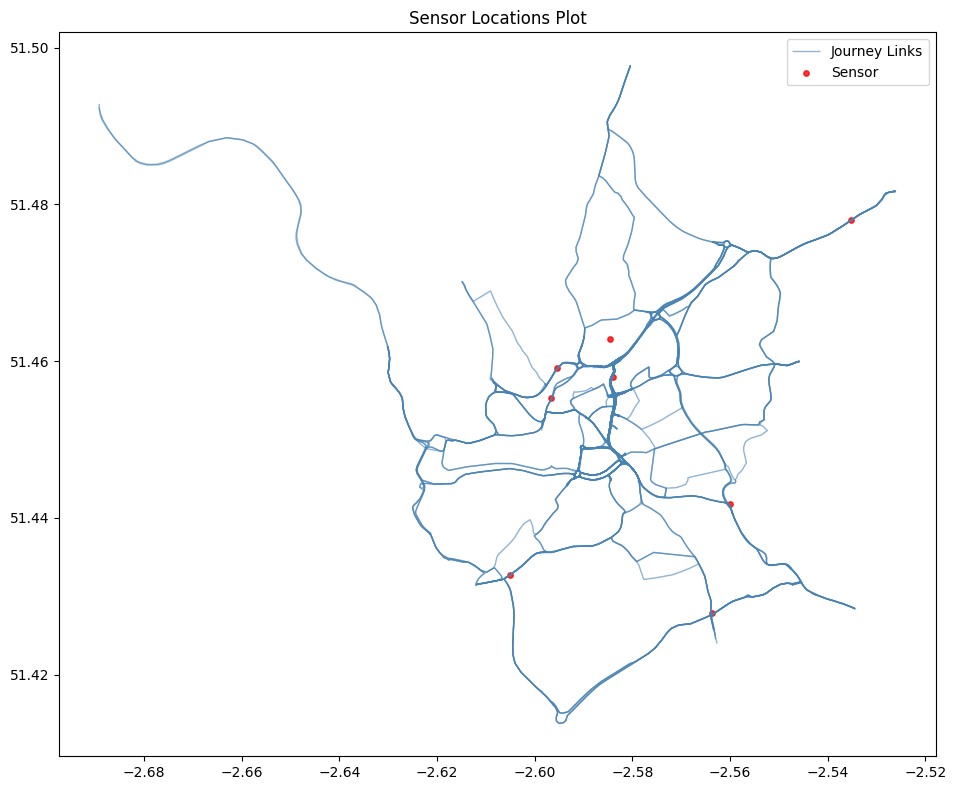

In [ ]:


fig, ax = plt.subplots(figsize=(10, 8))

# Plot GeoJSON layer first (base layer)
gdf.plot(ax=ax, color='steelblue', edgecolor='white',
         linewidth=1.0, alpha=0.6, label='Journey Links')

# Plot CSV points on top
gdf_sensor.plot(ax=ax, color='red', markersize=15,
             alpha=0.8, label='Sensor')

ax.set_title('Sensor Locations Plot')
ax.legend()
plt.tight_layout()
plt.show()

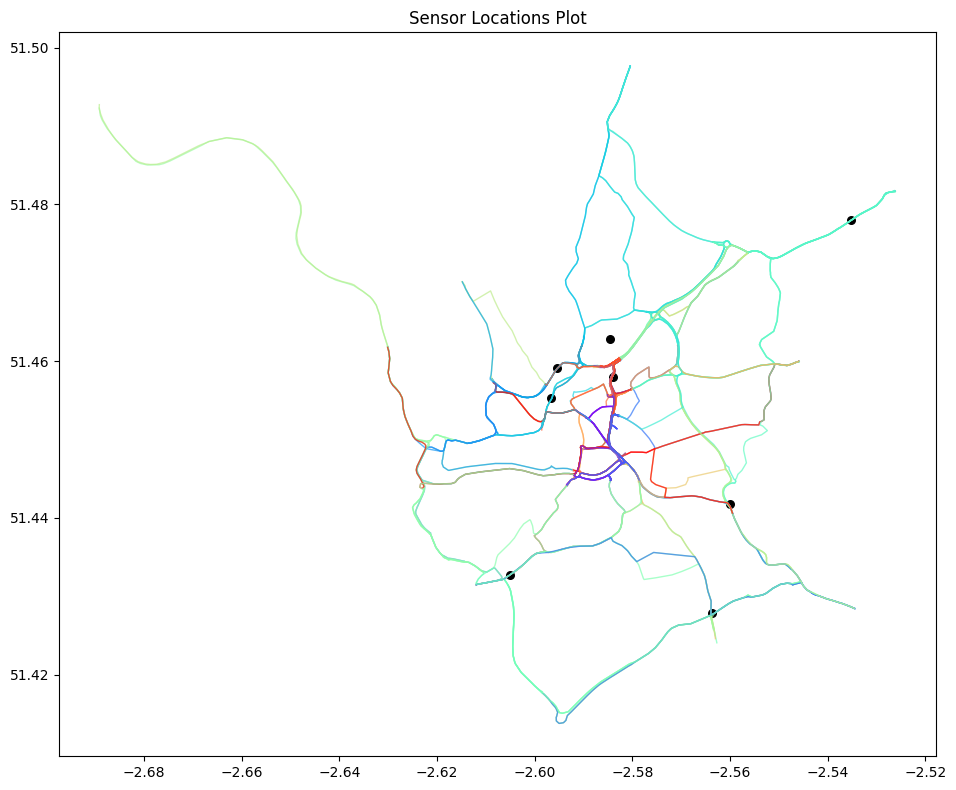

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot GeoJSON layer with colours by journey link
gdf.plot(ax=ax, column='JOURNEY_LINK_ID',  # replace 'journey_col' with your actual column name
         cmap='rainbow', linewidth=1.0, alpha=0.7,
         legend=False,
         legend_kwds={'title': 'Journey Links', 'bbox_to_anchor': (1, 1), 'loc': 'upper left', 'fontsize': 8})

# Plot CSV points on top
gdf_sensor.plot(ax=ax, color='black', markersize=30,
             alpha=1.0, label='Sensors')


ax.set_title('Sensor Locations Plot')
plt.tight_layout()
plt.show()

In [ ]:
# split each journey into segments
# label each segment with a unique segment ID
# add proportion of the whole road that line segment is
# add the parent ID
# plot an example
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from shapely.ops import unary_union, linemerge

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from shapely.ops import unary_union, linemerge

def create_line_segments_dataset(
    gdf,
    id_col="JOURNEY_LINK_ID",
    projected_crs=27700,
    output_crs=4326,
    min_length_m=None
):
    gdf_proj = gdf.to_crs(projected_crs).copy()
    segment_rows = []

    for parent_id, group in gdf_proj.groupby(id_col):
        merged = unary_union(group.geometry)

        if merged.is_empty:
            continue

        # Only linemerge if needed
        if merged.geom_type == "MultiLineString":
            merged = linemerge(merged)

        # Standardise into a list of lines
        if merged.geom_type == "LineString":
            lines = [merged]
        elif merged.geom_type == "MultiLineString":
            lines = list(merged.geoms)
        else:
            continue

        parent_segments = []

        for line in lines:
            coords = list(line.coords)

            for i in range(len(coords) - 1):
                seg = LineString([coords[i], coords[i + 1]])
                seg_len = seg.length

                if min_length_m is not None and seg_len < min_length_m:
                    continue

                parent_segments.append({
                    "geometry": seg,
                    "SEGMENT_LENGTH_M": seg_len
                })

        if not parent_segments:
            continue

        parent_length = sum(seg["SEGMENT_LENGTH_M"] for seg in parent_segments)

        for i, seg_data in enumerate(parent_segments, start=1):
            segment_rows.append({
                "PARENT_ID": parent_id,
                "SEGMENT_ID": f"{parent_id}_{i}",
                "SEGMENT_NO": i,
                "SEGMENT_LENGTH_M": seg_data["SEGMENT_LENGTH_M"],
                "PARENT_LENGTH_M": parent_length,
                "PARENT_PROPORTION": (
                    seg_data["SEGMENT_LENGTH_M"] / parent_length
                    if parent_length > 0 else None
                ),
                "geometry": seg_data["geometry"]
            })

    segments_gdf = gpd.GeoDataFrame(segment_rows, crs=projected_crs)

    if output_crs is not None:
        segments_gdf = segments_gdf.to_crs(output_crs)

    return segments_gdf

line_segments = create_line_segments_dataset(
    gdf,
    id_col="JOURNEY_LINK_ID",
    projected_crs=27700,
    output_crs=4326,
    min_length_m=None   # or try 5 if tiny segments are a problem
)
print(line_segments.head())
print(line_segments.columns)
print(f"Number of segment rows: {len(line_segments)}")
print(f"Unique parent IDs: {line_segments['PARENT_ID'].nunique()}")

  PARENT_ID SEGMENT_ID  SEGMENT_NO  SEGMENT_LENGTH_M  PARENT_LENGTH_M  \
0         1        1_1           1         92.682671       1347.48455   
1         1        1_2           2         30.701480       1347.48455   
2         1        1_3           3         21.821169       1347.48455   
3         1        1_4           4         35.173755       1347.48455   
4         1        1_5           5          5.731987       1347.48455   

   PARENT_PROPORTION                                           geometry  
0           0.068782  LINESTRING (-2.59344 51.44408, -2.59269 51.44477)  
1           0.022784  LINESTRING (-2.59269 51.44477, -2.59233 51.44493)  
2           0.016194  LINESTRING (-2.59233 51.44493, -2.59207 51.44504)  
3           0.026103  LINESTRING (-2.59207 51.44504, -2.59176 51.44529)  
4           0.004254  LINESTRING (-2.59176 51.44529, -2.59178 51.44534)  
Index(['PARENT_ID', 'SEGMENT_ID', 'SEGMENT_NO', 'SEGMENT_LENGTH_M',
       'PARENT_LENGTH_M', 'PARENT_PROPORTION', 'g

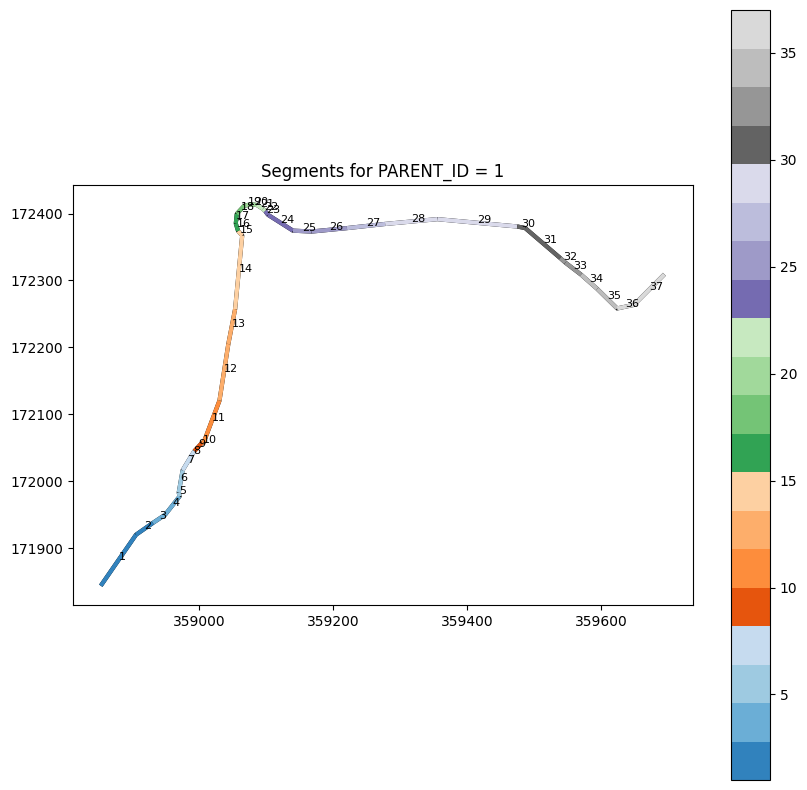

In [ ]:
# Pick the 6th unique parent ID
chosen_parent_id = line_segments["PARENT_ID"].unique()[0]

# Filter data
original_example = gdf[gdf["JOURNEY_LINK_ID"] == chosen_parent_id].copy()
segments_example = line_segments[line_segments["PARENT_ID"] == chosen_parent_id].copy()

if segments_example.empty:
    raise ValueError(f"No segments found for PARENT_ID = {chosen_parent_id}")

# Project for nicer plotting
original_example = original_example.to_crs(27700)
segments_example = segments_example.to_crs(27700)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

original_example.plot(ax=ax, linewidth=3, color="black", label="Original journey")

segments_example.plot(
    ax=ax,
    column="SEGMENT_NO",
    cmap="tab20c",
    linewidth=3,
    legend=True
)

for _, row in segments_example.iterrows():
    midpoint = row.geometry.interpolate(0.5, normalized=True)
    ax.text(midpoint.x, midpoint.y, str(row["SEGMENT_NO"]), fontsize=8)

ax.set_title(f"Segments for PARENT_ID = {chosen_parent_id}")
plt.show()

In [ ]:
# find the shortest distance from the segment to each sensor
gdf_sensor = gpd.GeoDataFrame(
    df_unique.copy(),
    geometry=gpd.points_from_xy(df_unique["EASTING"], df_unique["NORTHING"]),
    crs="EPSG:27700")

line_segments_proj = line_segments.to_crs(27700)

for _, sensor_row in gdf_sensor.iterrows():
    site_id = sensor_row["SITE_ID"]
    sensor_geom = sensor_row.geometry

    col_name = f"DIST_TO_SENSOR_{site_id}"
    line_segments[col_name] = line_segments_proj.geometry.distance(sensor_geom)

print(line_segments.head())

  PARENT_ID SEGMENT_ID  SEGMENT_NO  SEGMENT_LENGTH_M  PARENT_LENGTH_M  \
0         1        1_1           1         92.682671       1347.48455   
1         1        1_2           2         30.701480       1347.48455   
2         1        1_3           3         21.821169       1347.48455   
3         1        1_4           4         35.173755       1347.48455   
4         1        1_5           5          5.731987       1347.48455   

   PARENT_PROPORTION                                           geometry  \
0           0.068782  LINESTRING (-2.59344 51.44408, -2.59269 51.44477)   
1           0.022784  LINESTRING (-2.59269 51.44477, -2.59233 51.44493)   
2           0.016194  LINESTRING (-2.59233 51.44493, -2.59207 51.44504)   
3           0.026103  LINESTRING (-2.59207 51.44504, -2.59176 51.44529)   
4           0.004254  LINESTRING (-2.59176 51.44529, -2.59178 51.44534)   

   DIST_TO_SENSOR_203  DIST_TO_SENSOR_215  DIST_TO_SENSOR_270  \
0         2299.684423         1500.190791    

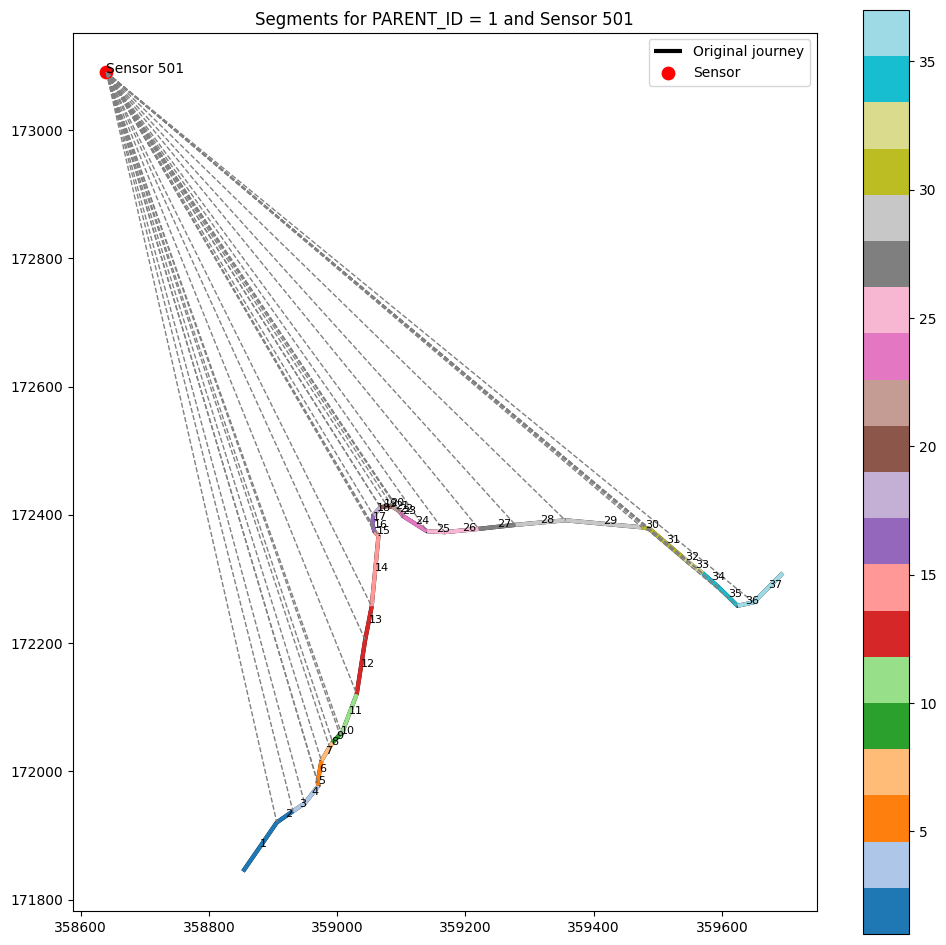

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import nearest_points
from shapely.geometry import LineString


chosen_parent_id = line_segments["PARENT_ID"].unique()[0]
chosen_site_id = df_unique["SITE_ID"].iloc[6]


gdf_sensor = gpd.GeoDataFrame(
    df_unique.copy(),
    geometry=gpd.points_from_xy(df_unique["EASTING"], df_unique["NORTHING"]),
    crs="EPSG:27700"
)


original_example = gdf[gdf["JOURNEY_LINK_ID"] == chosen_parent_id].copy().to_crs(27700)
segments_example = line_segments[line_segments["PARENT_ID"] == chosen_parent_id].copy().to_crs(27700)
sensor_example = gdf_sensor[gdf_sensor["SITE_ID"] == chosen_site_id].copy()

if segments_example.empty:
    raise ValueError(f"No segments found for PARENT_ID = {chosen_parent_id}")

if sensor_example.empty:
    raise ValueError(f"No sensor found for SITE_ID = {chosen_site_id}")

sensor_point = sensor_example.geometry.iloc[0]

fig, ax = plt.subplots(figsize=(12, 12))

# Original journey
original_example.plot(ax=ax, linewidth=3, color="black", label="Original journey")

# Segments in different colours
segments_example.plot(
    ax=ax,
    column="SEGMENT_NO",
    cmap="tab20",
    linewidth=3,
    legend=True
)

# Sensor point
sensor_example.plot(ax=ax, color="red", markersize=80, marker="o", label="Sensor")

# Label the sensor
ax.text(sensor_point.x, sensor_point.y, f"Sensor {chosen_site_id}", fontsize=10)

for _, row in segments_example.iterrows():
    seg = row.geometry

    # nearest point on segment to sensor
    point_on_seg, point_on_sensor = nearest_points(seg, sensor_point)

    # line showing shortest connection
    dist_line = LineString([point_on_seg, point_on_sensor])

    gpd.GeoSeries([dist_line], crs="EPSG:27700").plot(
        ax=ax,
        color="grey",
        linewidth=1,
        linestyle="--"
    )

    # label segment number near its midpoint
    midpoint = seg.interpolate(0.5, normalized=True)
    ax.text(midpoint.x, midpoint.y, str(row["SEGMENT_NO"]), fontsize=8)

ax.set_title(f"Segments for PARENT_ID = {chosen_parent_id} and Sensor {chosen_site_id}")
ax.set_aspect("equal")
ax.legend()
plt.show()

   CP_Number RoadNumber                                   geometry
0     6751.0       A201  LINESTRING (531660 180910, 531620 181220)
1     6767.0       A212  LINESTRING (535262 171567, 535465 171498)
2     7607.0      A3218  LINESTRING (525737 178270, 527007 179016)
3     8507.0      A1201  LINESTRING (531450 186770, 530265 187918)
4     8619.0       A300  LINESTRING (532355 180594, 532418 180818)


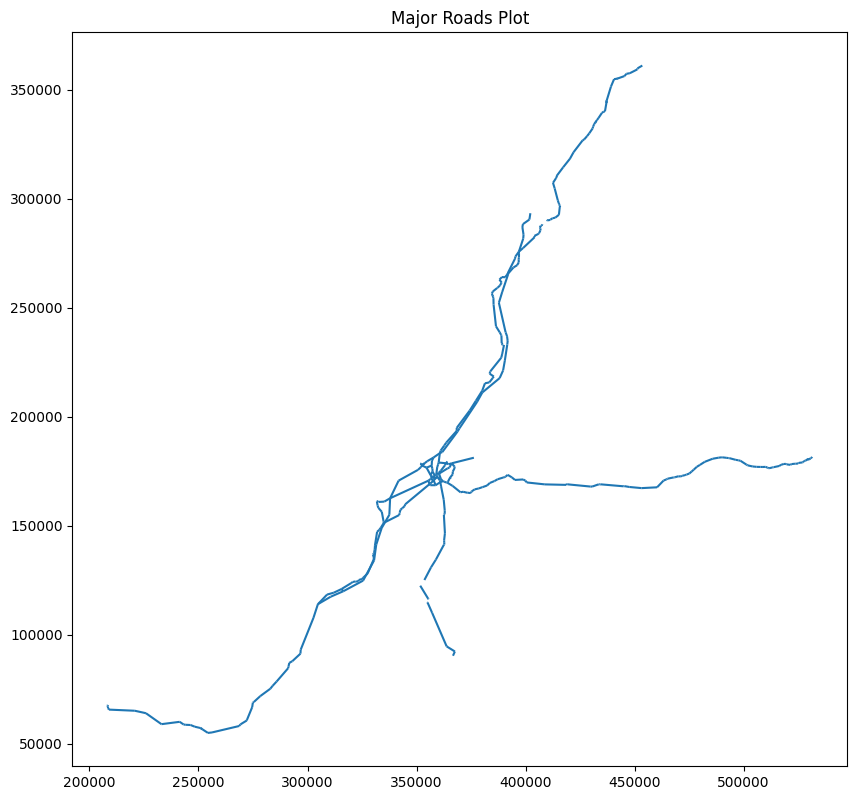

In [ ]:


# Replace this with your actual file path in Google Drive
zip_path = "/content/drive/MyDrive/mrdb-2023.zip"

# Read the zipped shapefile
gdf = gpd.read_file(zip_path)

print(gdf.head())
gdf_filtered = gdf[gdf['RoadNumber'].isin(['A3029', 'A37', 'A370', 'A38','A4','A4018','A4032',
                                           'A4044', 'A4162','A4174','A4176','A432','A4320','M32','M5'])]


# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_filtered.plot(ax=ax)
ax.set_title("Major Roads Plot")
plt.show()

   CP_Number RoadNumber                               geometry
0       51.0      A3111  LINESTRING (90120 10710, 90320 10530)
1       52.0      A3112  LINESTRING (90320 10530, 91650 10830)
2       53.0      A3111  LINESTRING (90320 10530, 91430 10900)
3       54.0      A3110  LINESTRING (91430 10900, 91650 10830)
4       55.0      A3110  LINESTRING (91430 10900, 91650 10830)


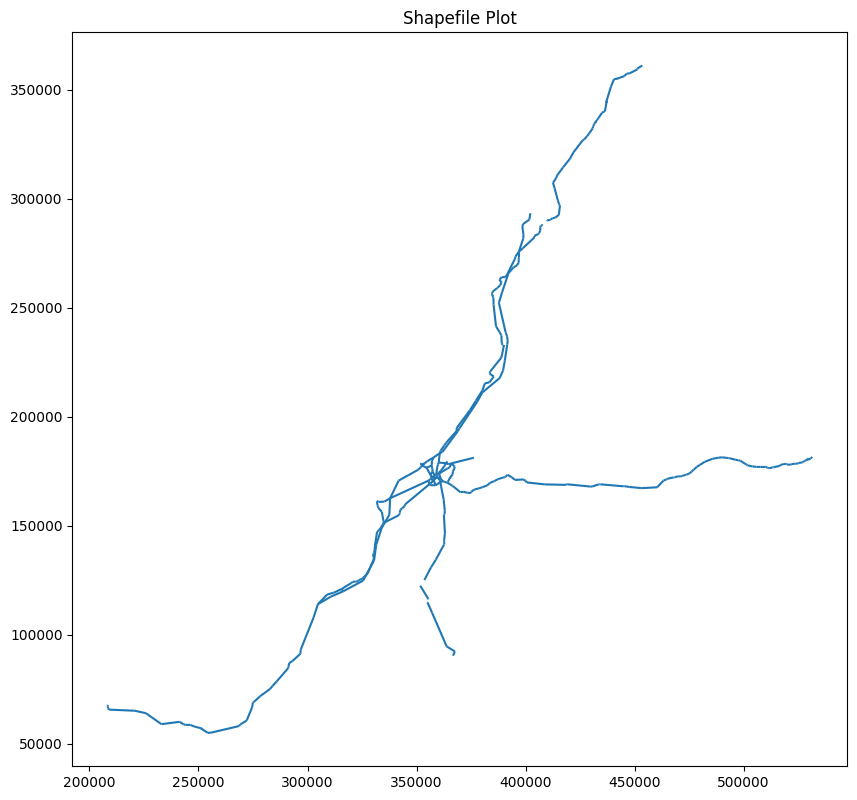

In [ ]:


# Replace this with your actual file path in Google Drive
zip_path = "/content/drive/MyDrive/mrdb-2024.zip"

# Read the zipped shapefile
gdf = gpd.read_file(zip_path)

# Check it loaded properly
print(gdf.head())
gdf_filtered_24 = gdf[gdf['RoadNumber'].isin(['A3029', 'A37', 'A370', 'A38','A4','A4018','A4032',
                                           'A4044', 'A4162','A4174','A4176','A432','A4320','M32','M5'])]

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_filtered_24.plot(ax=ax)
ax.set_title("Shapefile Plot")
plt.show()